<a href="https://colab.research.google.com/github/abhishekmohanty297/Deep_Learning/blob/main/CNN_CTTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [ ]:
import random
np.random.seed(0)

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
for i in range(0,10):
  print(i,':',len(x_train[y_train==i]))

0 : 5923
1 : 6742
2 : 5958
3 : 6131
4 : 5842
5 : 5421
6 : 5918
7 : 6265
8 : 5851
9 : 5949


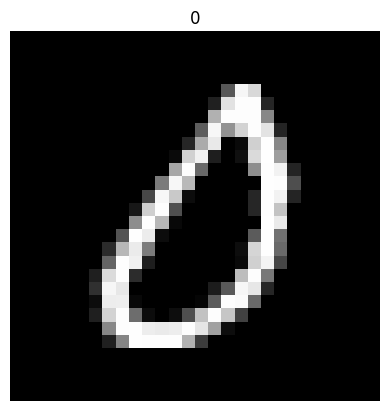

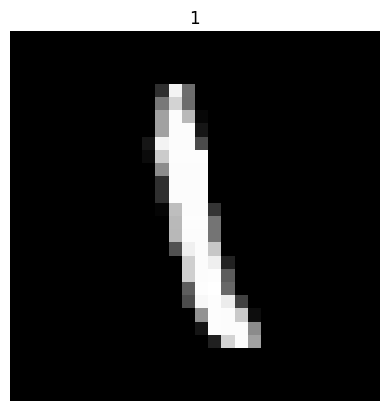

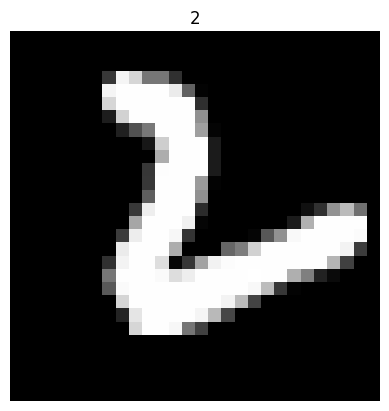

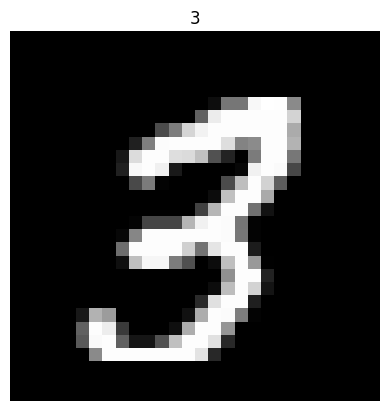

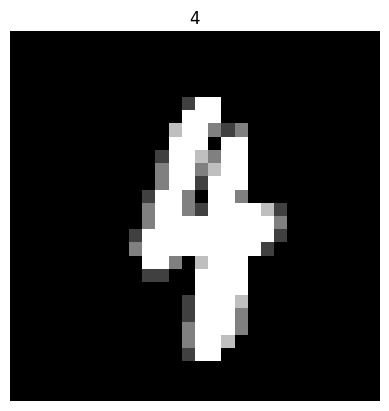

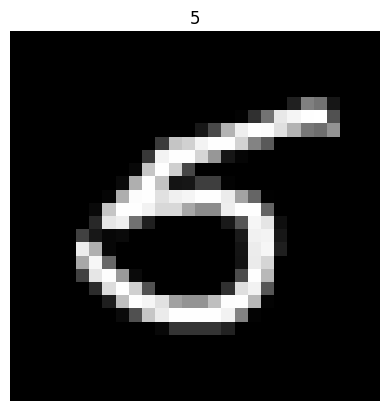

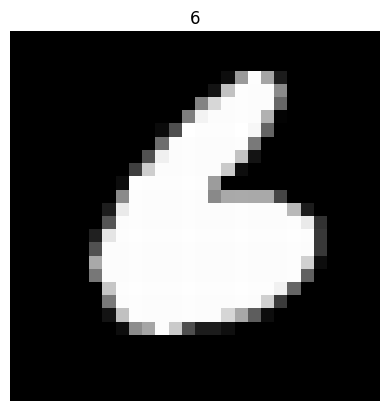

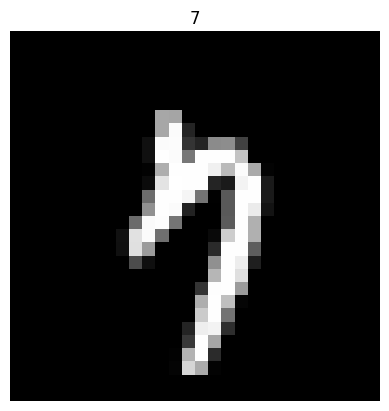

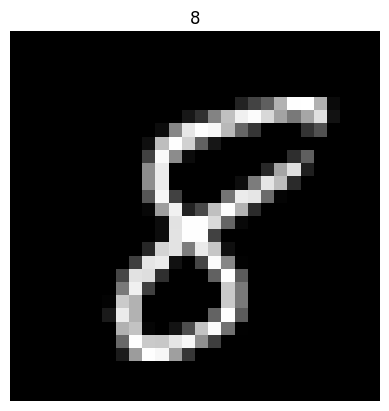

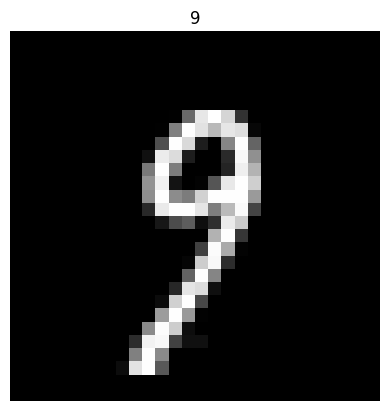

In [ ]:
for i in range(0,10):
  plt.imshow(x_train[y_train==i][np.random.randint(0,5000)],cmap='gray')
  plt.title(str(i))
  plt.axis('off')
  plt.show()

In [ ]:
from keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)
print(y_train.shape)

(60000, 10)


In [ ]:
x_train=x_train.reshape(60000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)

In [ ]:
x_train=x_train/255
x_test=x_test/255

In [ ]:
from keras.layers import Conv2D,MaxPool2D,Flatten

In [ ]:
def Lenet_Model():
  model=Sequential()
  model.add(Conv2D(30,(5,5),input_shape=(28,28,1),activation='relu'))
  model.add(MaxPool2D(pool_size=(2,2)))
  model.add(Conv2D(15,(3,3),activation='relu'))
  model.add(MaxPool2D(pool_size=(2,2)))
  model.add(Flatten())
  model.add(Dense(200,activation='relu'))
  model.add(Dense(100,activation='relu'))
  model.add(Dense(10,activation='softmax'))
  model.compile(Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])
  return model

In [ ]:
model=Lenet_Model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
h=model.fit(x_train,y_train,validation_split=0.2,epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.8982 - loss: 0.3288 - val_accuracy: 0.9649 - val_loss: 0.1280
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.9667 - loss: 0.1247 - val_accuracy: 0.9732 - val_loss: 0.1130
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9734 - loss: 0.1042 - val_accuracy: 0.9558 - val_loss: 0.1832
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9748 - loss: 0.0993 - val_accuracy: 0.9766 - val_loss: 0.1020
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9757 - loss: 0.0995 - val_accuracy: 0.9722 - val_loss: 0.1267
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9785 - loss: 0.0940 - val_accuracy: 0.9619 - val_loss: 0.2013
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9781 - loss: 0.0937 - val_accuracy: 0.9715 - val_loss: 0.1725
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9792 -

In [ ]:
from google.colab import files
c=files.upload()

Saving mnist_image.png to mnist_image (1).png


In [ ]:
d=list(c.keys())[0]
print(d)

mnist_image (1).png


In [ ]:
a=np.fromstring(c[d],np.uint8)
print(a)

[137  80  78 ...  66  96 130]


/tmp/ipython-input-301/1462506825.py:1: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  a=np.fromstring(c[d],np.uint8)


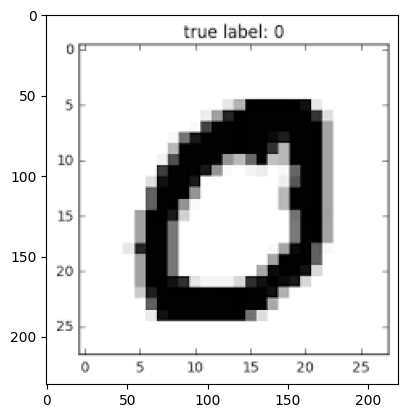

In [ ]:
import cv2
img=cv2.imdecode(a,cv2.IMREAD_COLOR)
plt.imshow(img,cmap='gray')
plt.show()

In [ ]:
img.shape

(230, 219, 3)

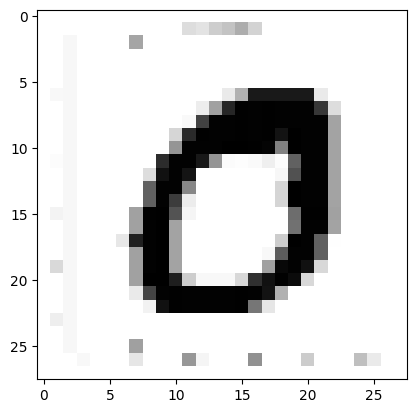

In [ ]:
img=cv2.resize(img,(28,28))
img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(img,cmap='gray')
plt.show()

In [ ]:
img=img/255
img=img.reshape(1,28,28,1)

In [ ]:
pred=model.predict(img)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


array([[4.3809023e-03, 2.4207062e-04, 4.9984832e-03, 7.6376104e-01,
        1.8027105e-05, 2.1054384e-01, 1.4425378e-04, 2.9960570e-03,
        7.1186209e-03, 5.7966751e-03]], dtype=float32)

In [ ]:
p=np.argmax(pred,axis=1)
p

array([3])